In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from shapely.geometry import Point
import geopandas as gpd
from geopandas import GeoDataFrame
import geodatasets

In [4]:
df = pd.read_csv("../../el_nino.csv")
df

,year,month,day,date,latitude,longitude,zon_winds,mer_winds,humidity,air_temp,ss_temp
0,80,3,7,800307,-0.02,-109.46,-6.8,0.7,NaN,26.14,26.24
1,80,3,8,800308,-0.02,-109.46,-4.9,1.1,NaN,25.66,25.97
2,80,3,9,800309,-0.02,-109.46,-4.5,2.2,NaN,25.69,25.28
3,80,3,10,800310,-0.02,-109.46,-3.8,1.9,NaN,25.57,24.31
4,80,3,11,800311,-0.02,-109.46,-4.2,1.5,NaN,25.30,23.19
...,...,...,...,...,...,...,...,...,...,...,...
178075,98,6,11,980611,8.96,-140.33,-5.1,-0.4,94.1,26.04,28.14
178076,98,6,12,980612,8.96,-140.32,-4.3,-3.3,93.2,25.80,27.87
178077,98,6,13,980613,8.95,-140.34,-6.1,-4.8,81.3,27.17,27.93
178078,98,6,14,980614,8.96,-140.33,-4.9,-2.3,76.2,27.36,28.03


In [5]:
df.isna().mean() * 100

year          0.000000
month         0.000000
day           0.000000
date          0.000000
latitude      0.000000
longitude     0.000000
zon_winds    14.130166
mer_winds    14.129605
humidity     36.927785
air_temp     10.240903
ss_temp       9.550202
dtype: float64

In [6]:
# df_cleaned = df.dropna()
df_cleaned = df.sort_values(by='date')
df_cleaned = df_cleaned.dropna(thresh=10)

# set hemisphere column
df_cleaned["hemisphere"] = "west"
df_cleaned.loc[df_cleaned["longitude"] <= -50, "hemisphere"] = "east"

df_cleaned["date"] = pd.to_datetime(df_cleaned["date"].astype(str), format="%y%m%d")

df_cleaned

,year,month,day,date,latitude,longitude,zon_winds,mer_winds,humidity,air_temp,ss_temp,hemisphere
0,80,3,7,1980-03-07,-0.02,-109.46,-6.8,0.7,NaN,26.14,26.24,east
1,80,3,8,1980-03-08,-0.02,-109.46,-4.9,1.1,NaN,25.66,25.97,east
2,80,3,9,1980-03-09,-0.02,-109.46,-4.5,2.2,NaN,25.69,25.28,east
3,80,3,10,1980-03-10,-0.02,-109.46,-3.8,1.9,NaN,25.57,24.31,east
4,80,3,11,1980-03-11,-0.02,-109.46,-4.2,1.5,NaN,25.30,23.19,east
...,...,...,...,...,...,...,...,...,...,...,...,...
171397,98,6,22,1998-06-22,-7.98,-170.03,-4.2,-3.5,81.1,28.41,29.19,east
164733,98,6,22,1998-06-22,-7.97,-125.02,-4.3,-1.8,66.0,27.18,NaN,east
151886,98,6,22,1998-06-22,8.08,156.02,-5.6,-3.1,86.5,28.41,28.96,west
159854,98,6,22,1998-06-22,8.05,-94.94,7.1,2.1,89.4,27.40,NaN,east


In [7]:
dupes = (
    df_cleaned.groupby(["year", "month", "day"])
      .size()
      .loc[lambda x: x > 1]
      .reset_index(name="repeat_count")
)
dupes.sort_values(by="repeat_count", ascending=False, inplace=True)
dupes.head(40)

,year,month,day,repeat_count
3600,94,12,21,59
3598,94,12,19,59
3599,94,12,20,59
3623,95,1,13,58
3631,95,1,21,58
3616,95,1,6,58
3620,95,1,10,58
3619,95,1,9,58
3622,95,1,12,58
3596,94,12,17,58


In [8]:
elnino = [
          "1991-01-01",
          "1991-06-01",
          "1993-01-01", 
          "1994-01-01",  
          "1997-01-01", 
        ]

def plot_vertical_lines():
    for year in elnino:
        plt.axvline(pd.Timestamp(year), color="black", linestyle="--", alpha=0.4)


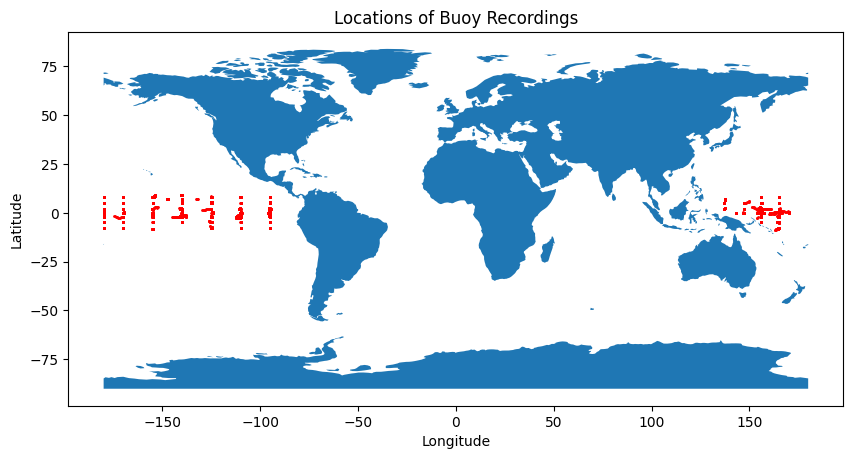

In [9]:
locations = df_cleaned[["latitude", "longitude"]].drop_duplicates()

geometry = [Point(xy) for xy in zip(locations['longitude'], locations['latitude'])]
gdf = GeoDataFrame(locations, geometry=geometry)

world = gpd.read_file(geodatasets.data.naturalearth.land['url'])

# Create figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

# Plot base map
world.plot(ax=ax)

# Plot points
gdf.plot(ax=ax, marker='o', color='red', markersize=1)

# Add title and labels
ax.set_title("Locations of Buoy Recordings")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.show()


In [10]:
# df_grouped = df_cleaned.group
df_grouped = df_cleaned.groupby(["year", "month", "day", "date", "hemisphere"]).mean()
df_grouped.reset_index(inplace=True)
df_grouped


,year,month,day,date,hemisphere,latitude,longitude,zon_winds,mer_winds,humidity,air_temp,ss_temp
0,80,3,7,1980-03-07,east,-0.020,-109.460000,-6.800000,0.700000,NaN,26.140000,26.240000
1,80,3,8,1980-03-08,east,-0.020,-109.460000,-4.900000,1.100000,NaN,25.660000,25.970000
2,80,3,9,1980-03-09,east,-0.020,-109.460000,-4.500000,2.200000,NaN,25.690000,25.280000
3,80,3,10,1980-03-10,east,-0.020,-109.460000,-3.800000,1.900000,NaN,25.570000,24.310000
4,80,3,11,1980-03-11,east,-0.020,-109.460000,-4.200000,1.500000,NaN,25.300000,23.190000
...,...,...,...,...,...,...,...,...,...,...,...,...
10346,98,6,21,1998-06-21,east,1.640,-141.883750,-3.737500,0.362500,79.385714,27.621250,28.761667
10347,98,6,21,1998-06-21,west,4.218,159.660000,-5.140000,-0.760000,86.160000,27.886000,29.152500
10348,98,6,22,1998-06-22,east,-0.978,-146.012000,-2.360000,-2.320000,81.560000,27.754000,29.000000
10349,98,6,22,1998-06-22,west,3.690,162.096667,-4.833333,-3.366667,83.033333,28.433333,29.170000


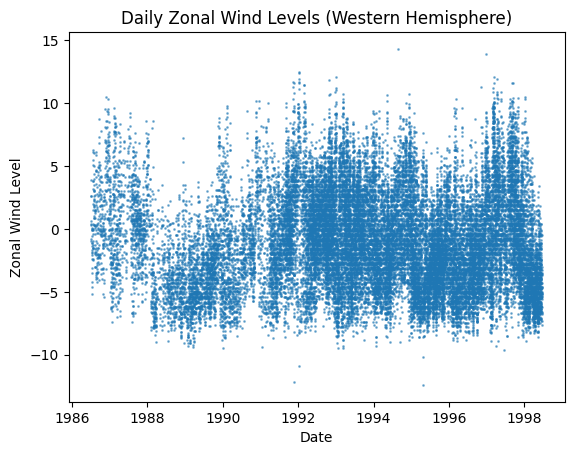

In [11]:
plt.scatter(df_cleaned[df_cleaned["hemisphere"] == "west"]["date"], df_cleaned[df_cleaned["hemisphere"] == "west"]["zon_winds"], label="West", marker="o",alpha=0.5, s=1)

plt.xlabel("Date")
plt.ylabel("Zonal Wind Level")
plt.title("Daily Zonal Wind Levels (Western Hemisphere)")

plt.show()

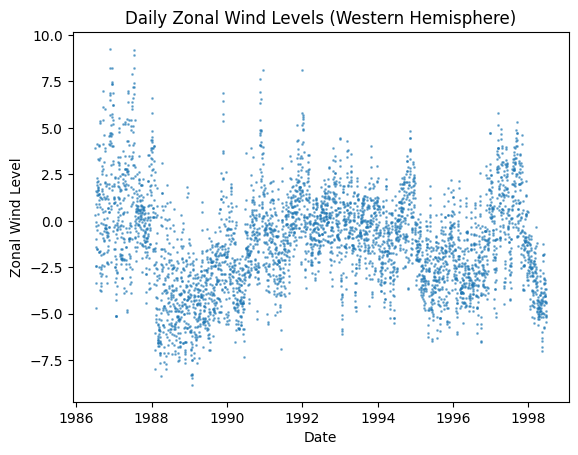

In [12]:
plt.scatter(df_grouped[df_grouped["hemisphere"] == "west"]["date"], df_grouped[df_grouped["hemisphere"] == "west"]["zon_winds"], label="West", marker="o",alpha=0.5, s=1)

plt.xlabel("Date")
plt.ylabel("Zonal Wind Level")
plt.title("Daily Zonal Wind Levels (Western Hemisphere)")

plt.show()

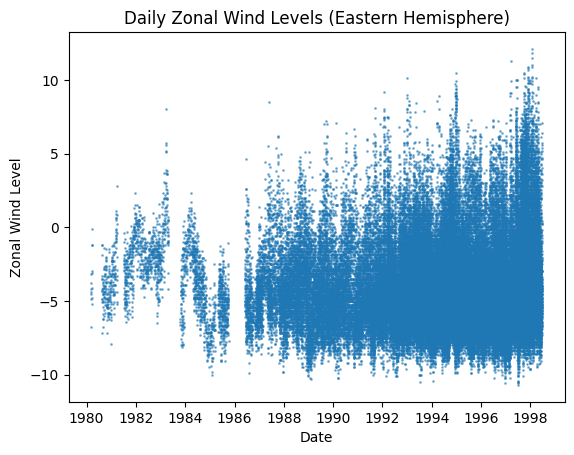

In [13]:
plt.scatter(df_cleaned[df_cleaned["hemisphere"] == "east"]["date"], df_cleaned[df_cleaned["hemisphere"] == "east"]["zon_winds"], label="East", marker="o",alpha=0.5, s=1)

plt.xlabel("Date")
plt.ylabel("Zonal Wind Level")
plt.title("Daily Zonal Wind Levels (Eastern Hemisphere)")

plt.show()

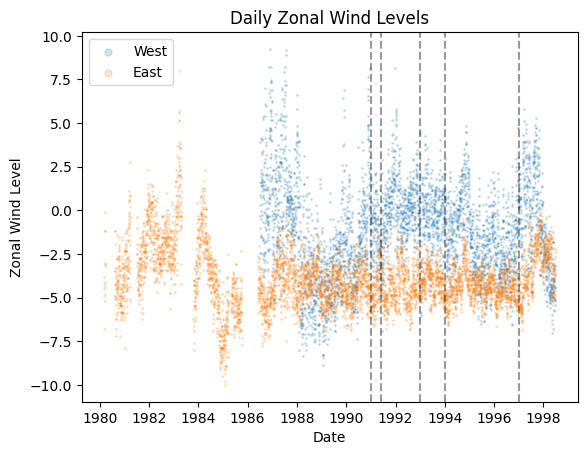

In [14]:
plt.scatter(df_grouped[df_grouped["hemisphere"] == "west"]["date"], df_grouped[df_grouped["hemisphere"] == "west"]["zon_winds"], label="West", marker="o",alpha=0.2, s=1)
plt.scatter(df_grouped[df_grouped["hemisphere"] == "east"]["date"], df_grouped[df_grouped["hemisphere"] == "east"]["zon_winds"], label="East", marker="o",alpha=0.2, s=1)

plt.xlabel("Date")
plt.ylabel("Zonal Wind Level")
plt.title("Daily Zonal Wind Levels")
plt.legend(markerscale=5)
plot_vertical_lines()

plt.show()

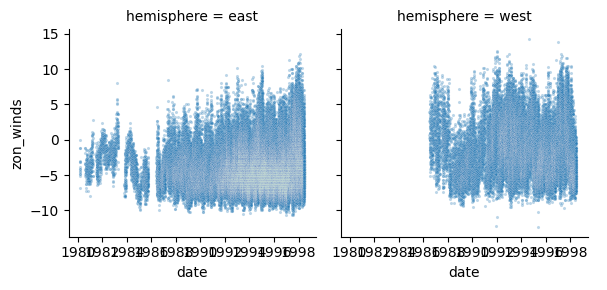

In [15]:
g = sns.FacetGrid(df_cleaned, col="hemisphere")
g.map(sns.scatterplot, "date", "zon_winds", alpha=.3, s=5)
g.add_legend()

In [16]:
west = df_grouped[df_grouped["hemisphere"] == "west"]
east = df_grouped[df_grouped["hemisphere"] == "east"]

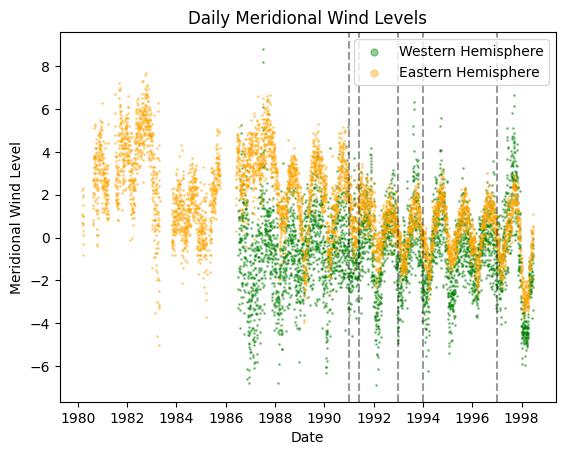

In [24]:
plt.scatter(west["date"], west["mer_winds"], label="Western Hemisphere", marker="o",alpha=0.4, s=1, color="green")
plt.scatter(east["date"], east["mer_winds"], label="Eastern Hemisphere", marker="o",alpha=0.4, s=1, color="orange")
plt.xlabel("Date")
plt.ylabel("Meridional Wind Level")
plt.title("Daily Meridional Wind Levels")
plt.legend(markerscale=5)

plot_vertical_lines()
plt.show()

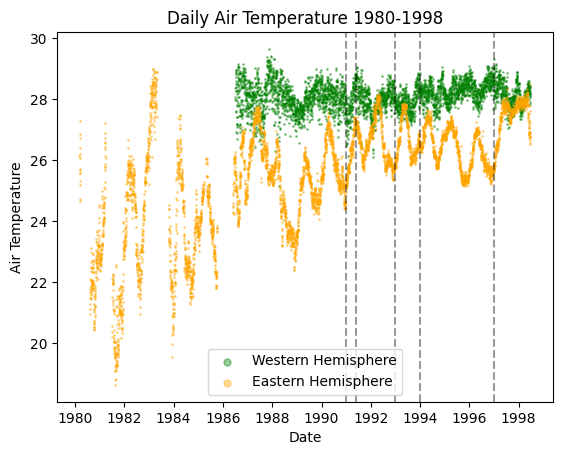

In [25]:
plt.scatter(west["date"], west["air_temp"], label="Western Hemisphere", marker="o",alpha=0.4, s=1, color="green")
plt.scatter(east["date"], east["air_temp"], label="Eastern Hemisphere", marker="o",alpha=0.4, s=1, color="orange")
plt.xlabel("Date")
plt.ylabel("Air Temperature")
plt.title("Daily Air Temperature 1980-1998")
plt.legend(markerscale=5)

plot_vertical_lines()
plt.show()

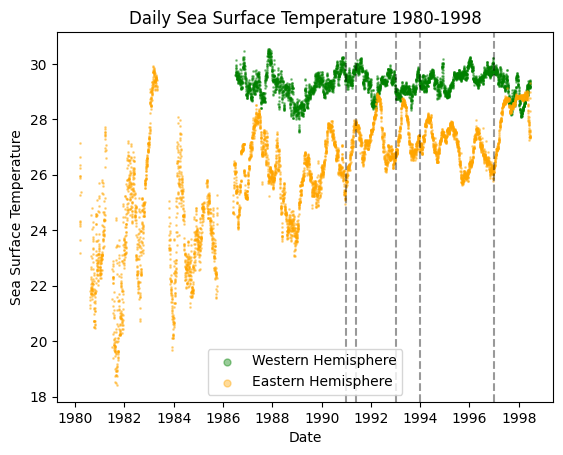

In [26]:
plt.scatter(west["date"], west["ss_temp"], label="Western Hemisphere", marker="o",alpha=0.4, s=1, color="green")
plt.scatter(east["date"], east["ss_temp"], label="Eastern Hemisphere", marker="o",alpha=0.4, s=1, color="orange")
plt.xlabel("Date")
plt.ylabel("Sea Surface Temperature")
plt.title("Daily Sea Surface Temperature 1980-1998")
plt.legend(markerscale=5)

plot_vertical_lines()
plt.show()

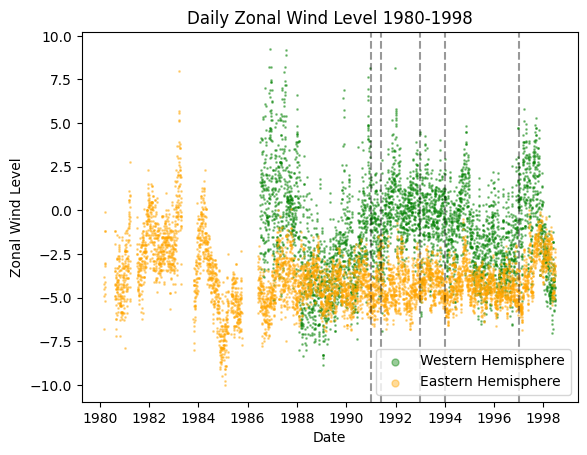

In [28]:
plt.scatter(west["date"], west["zon_winds"], label="Western Hemisphere", marker="o",alpha=0.4, s=1, color="green")
plt.scatter(east["date"], east["zon_winds"], label="Eastern Hemisphere", marker="o",alpha=0.4, s=1, color="orange")
plt.xlabel("Date")
plt.ylabel("Zonal Wind Level")
plt.title("Daily Zonal Wind Level 1980-1998")
plt.legend(markerscale=5)

plot_vertical_lines()
plt.show()

In [32]:
after_90 = df_grouped[df_grouped["year"] >= 90]
after_90.head()

,year,month,day,date,hemisphere,latitude,longitude,zon_winds,mer_winds,humidity,air_temp,ss_temp
4160,90,1,1,1990-01-01,east,2.857778,-134.178889,-5.322222,3.377778,84.20,25.435556,26.296667
4161,90,1,1,1990-01-01,west,1.328333,165.006667,-1.766667,-2.366667,NaN,28.575000,29.645000
4162,90,1,2,1990-01-02,east,2.374000,-134.761000,-4.510000,2.670000,82.35,25.492000,26.187000
4163,90,1,2,1990-01-02,west,1.328333,165.000000,-1.966667,-0.683333,NaN,28.481667,29.718333
4164,90,1,3,1990-01-03,east,2.365000,-134.755000,-4.790000,1.840000,81.05,25.264000,26.086000


In [33]:
west = after_90[after_90["hemisphere"] == "west"]
east = after_90[after_90["hemisphere"] == "east"]



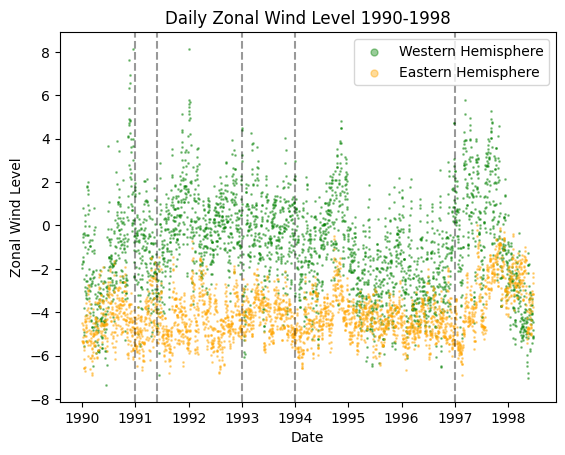

In [39]:
plt.scatter(west["date"], west["zon_winds"], label="Western Hemisphere", marker="o",alpha=0.4, s=1, color="green")
plt.scatter(east["date"], east["zon_winds"], label="Eastern Hemisphere", marker="o",alpha=0.4, s=1, color="orange")
plt.xlabel("Date")
plt.ylabel("Zonal Wind Level")
plt.title("Daily Zonal Wind Level 1990-1998")
plt.legend(markerscale=5)

plot_vertical_lines()
plt.show()

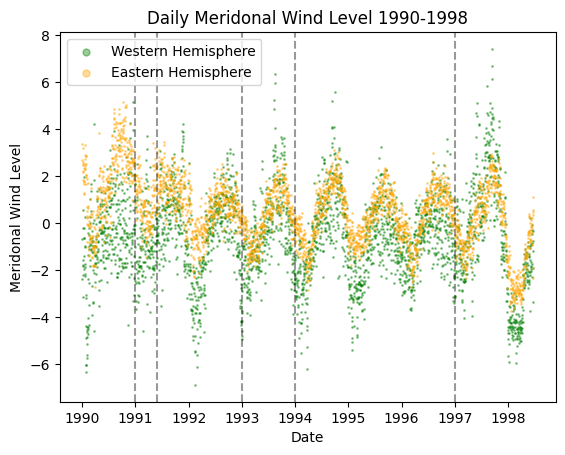

In [38]:
plt.scatter(west["date"], west["mer_winds"], label="Western Hemisphere", marker="o",alpha=0.4, s=1, color="green")
plt.scatter(east["date"], east["mer_winds"], label="Eastern Hemisphere", marker="o",alpha=0.4, s=1, color="orange")
plt.xlabel("Date")
plt.ylabel("Meridonal Wind Level")
plt.title("Daily Meridonal Wind Level 1990-1998")
plt.legend(markerscale=5)

plot_vertical_lines()
plt.show()

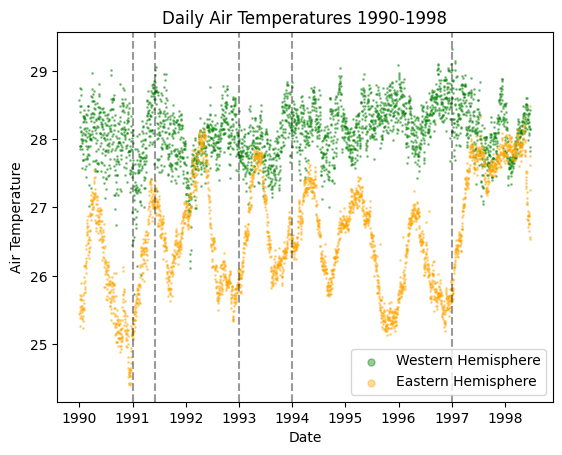

In [36]:
plt.scatter(west["date"], west["air_temp"], label="Western Hemisphere", marker="o",alpha=0.4, s=1, color="green")
plt.scatter(east["date"], east["air_temp"], label="Eastern Hemisphere", marker="o",alpha=0.4, s=1, color="orange")
plt.xlabel("Date")
plt.ylabel("Air Temperature")
plt.title("Daily Air Temperatures 1990-1998")
plt.legend(markerscale=5)

plot_vertical_lines()
plt.show()

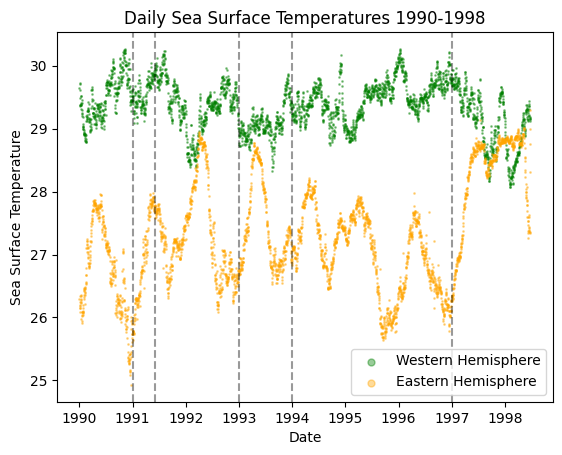

In [ ]:
plt.scatter(west["date"], west["ss_temp"], label="Western Hemisphere", marker="o",alpha=0.4, s=1, color="green")
plt.scatter(east["date"], east["ss_temp"], label="Eastern Hemisphere", marker="o",alpha=0.4, s=1, color="orange")
plt.xlabel("Date")
plt.ylabel("Sea Surface Temperature")
plt.title("Daily Sea Surface Temperatures 1990-1998")
plt.legend(markerscale=5)

plot_vertical_lines()
plt.show()

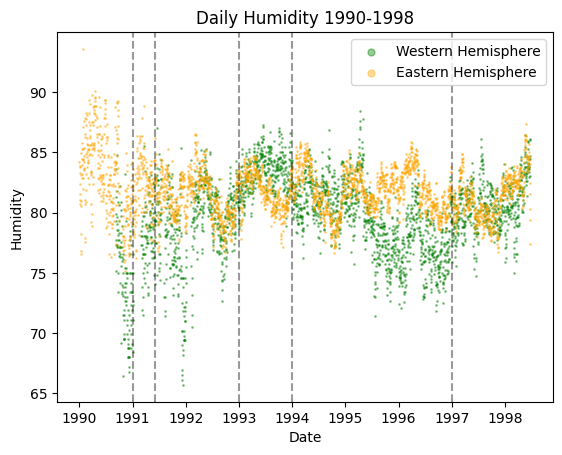

In [40]:
plt.scatter(west["date"], west["humidity"], label="Western Hemisphere", marker="o",alpha=0.4, s=1, color="green")
plt.scatter(east["date"], east["humidity"], label="Eastern Hemisphere", marker="o",alpha=0.4, s=1, color="orange")
plt.xlabel("Date")
plt.ylabel("Humidity")
plt.title("Daily Humidity 1990-1998")
plt.legend(markerscale=5)

plot_vertical_lines()
plt.show()